 pymupdf package find tables method

In [17]:
import cv2
import numpy as np
import cv2
import matplotlib.pyplot as plt

def display_img(result_img):
    # Convert ONCE for matplotlib and show
    result_rgb = cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(result_rgb)
    plt.axis("on")
    plt.show()

In [11]:
import pymupdf

def extract_tables_from_pdf(pdf_path):
    """Extract tables directly from PDF using PyMuPDF"""
    with pymupdf.open(pdf_path) as doc:
        all_tables = []
        for page_num, page in enumerate(doc):
            tables = page.find_tables()
            for i, table in enumerate(tables):
                table_data = table.extract()
                all_tables.append({
                    'page': page_num + 1,
                    'table_index': i + 1,
                    'data': table_data
                })
                print(f"Page {page_num + 1}, Table {i + 1}:")
                print(table_data)
        return all_tables

In [ ]:
# Import required packages:
import cv2
from matplotlib import pyplot as plt

# Load the image and convert it to grayscale:
image = cv2.imread("docs/olympic_paper.jpg")
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Calculate the histogram
hist = cv2.calcHist([gray_image], [0], None, [256], [0, 256])

# Otsu's binarization algorithm:
ret1, th1 = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

#  Blurs the image using a Gaussian filter to eliminate noise
gray_image_blurred = cv2.GaussianBlur(gray_image, (25, 25), 0)

# Calculate histogram after filtering:
hist2 = cv2.calcHist([gray_image_blurred], [0], None, [256], [0, 256])

# Otsu's binarization algorithm:
ret2, th2 = cv2.threshold(gray_image_blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt

In [101]:
def get_txt_position_under_shape(
        text,
        contour,
        font_face,
        font_scale,
        thickness,
        padding=20):
    """
    Returns coordinates to draw text under a contour
    """

    # text size
    text_size = cv2.getTextSize(
        text,
        font_face,
        font_scale,
        thickness
    )[0]

    # bounding box of contour
    x, y, w, h = cv2.boundingRect(contour)

    # center text horizontally under shape
    text_x = x + (w - text_size[0]) / 2

    # position below shape
    text_y = y + h + padding+40

    return round(text_x), round(text_y)

detected contours number: '162' 
(4, 1, 2)
(4, 2)

Name square

(6, 1, 2)
(6, 2)

Name hexagon

(8, 1, 2)
(8, 2)

Name circle

(9, 1, 2)
(9, 2)

Name circle

(6, 1, 2)
(6, 2)

Name hexagon

(6, 1, 2)
(6, 2)

Name hexagon

(9, 1, 2)
(9, 2)

Name circle

(7, 1, 2)
(7, 2)

Name circle

(8, 1, 2)
(8, 2)

Name circle

(9, 1, 2)
(9, 2)

Name circle

(4, 1, 2)
(4, 2)

Name rectangle

(4, 1, 2)
(4, 2)

Name rectangle

(6, 1, 2)
(6, 2)

Name hexagon

(6, 1, 2)
(6, 2)

Name hexagon

(8, 1, 2)
(8, 2)

Name circle

(6, 1, 2)
(6, 2)

Name hexagon

(5, 1, 2)
(5, 2)

Name pentagon

(8, 1, 2)
(8, 2)

Name circle

(7, 1, 2)
(7, 2)

Name circle

(8, 1, 2)
(8, 2)

Name circle

(8, 1, 2)
(8, 2)

Name circle

(7, 1, 2)
(7, 2)

Name circle

(8, 1, 2)
(8, 2)

Name circle

(9, 1, 2)
(9, 2)

Name circle

(6, 1, 2)
(6, 2)

Name hexagon

(8, 1, 2)
(8, 2)

Name circle

(8, 1, 2)
(8, 2)

Name circle

(5, 1, 2)
(5, 2)

Name pentagon

(4, 1, 2)
(4, 2)

Name square

(7, 1, 2)
(7, 2)

Name circle

(7, 1, 2)
(7, 2)

Na

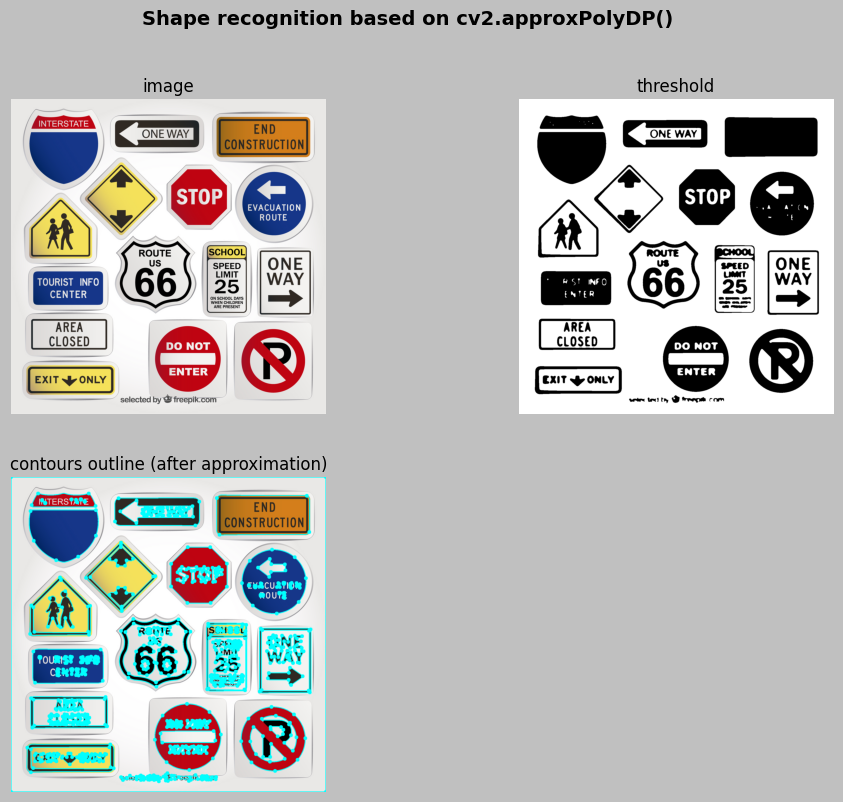

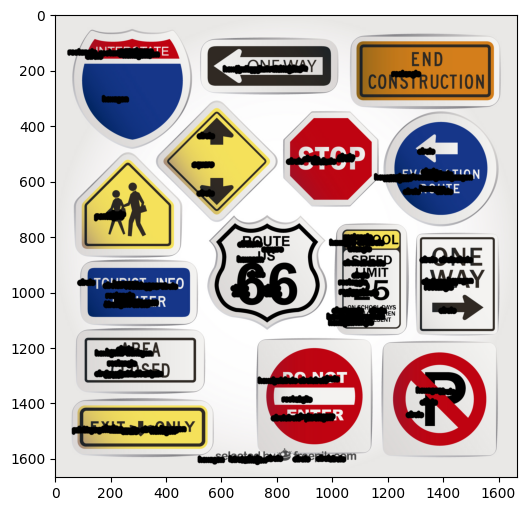

In [104]:
"""
Contours shape recognition mainly based on cv2.approxPolyDP() function
"""

# Import required packages:
import numpy as np
import cv2
from matplotlib import pyplot as plt


def get_position_to_draw(text, point, font_face, font_scale, thickness):
    """Gives the coordinates to draw centered"""

    text_size = cv2.getTextSize(text, font_face, font_scale, thickness)[0]
    text_x = point[0] - text_size[0] / 2
    text_y = point[1] + text_size[1] / 2
    return round(text_x), round(text_y)


def detect_shape(contour):
    """Returns the shape (e.g. 'triangle', 'square') from the contour"""

    detected_shape = '-----'

    # Calculate perimeter of the contour:
    perimeter = cv2.arcLength(contour, True)

    # Get a contour approximation:
    contour_approx = cv2.approxPolyDP(contour, 0.03 * perimeter, True)

    # Check if the number of vertices is 3. In this case, the contour is a triangle
    if len(contour_approx) == 3:
        detected_shape = 'triangle'

    # Check if the number of vertices is 4. In this case, the contour is a square/rectangle
    elif len(contour_approx) == 4:

        # We calculate the aspect ration from the bounding rect:
        x, y, width, height = cv2.boundingRect(contour_approx)
        aspect_ratio = float(width) / height

        # A square has an aspect ratio close to 1 (comparison chaining is used):
        if 0.90 < aspect_ratio < 1.10:
            detected_shape = "square"
        else:
            detected_shape = "rectangle"

    # Check if the number of vertices is 5. In this case, the contour is a pentagon
    elif len(contour_approx) == 5:
        detected_shape = "pentagon"

    # Check if the number of vertices is 6. In this case, the contour is a hexagon
    elif len(contour_approx) == 6:
        detected_shape = "hexagon"

    # The shape as more than 6 vertices. In this example, we assume that is a circle
    else:
        detected_shape = "circle"

    # return the name of the shape and the found vertices
    return detected_shape, contour_approx


def array_to_tuple(arr):
    """Converts array to tuple"""

    return tuple(arr.reshape(1, -1)[0])


def draw_contour_points(img, cnts, color):
    """Draw all points from a list of contours"""

    for cnt in cnts:
        print(cnt.shape)
        squeeze = np.squeeze(cnt)
        print(squeeze.shape)

        for p in squeeze:
            pp = array_to_tuple(p)
            cv2.circle(img, pp, 10, color, -1)

    return img


def draw_contour_outline(img, cnts, color, thickness=1):
    """Draws contours outlines of each contour"""

    for cnt in cnts:
        cv2.drawContours(img, [cnt], 0, color, thickness)


def show_img_with_matplotlib(color_img, title, pos):
    """Shows an image using matplotlib capabilities"""

    # Convert BGR image to RGB
    img_RGB = color_img[:, :, ::-1]

    plt.subplot(2, 2, pos)
    plt.imshow(img_RGB)
    plt.title(title)
    plt.axis('off')


# Create the dimensions of the figure and set title:
fig = plt.figure(figsize=(12, 9))
plt.suptitle("Shape recognition based on cv2.approxPolyDP()", fontsize=14, fontweight='bold')
fig.patch.set_facecolor('silver')


#!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
# Load the image and convert it to grayscale:
# image = build_sample_image_2()
image = cv2.imread("docs/road_signs2.jpg")
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray_image_blurred = cv2.GaussianBlur(gray_image, (25, 25), 0) #added DN
# Apply cv2.threshold() to get a binary image:
#ret, thresh = cv2.threshold(gray_image, 50, 255, cv2.THRESH_BINARY)
#_, thresh = cv2.threshold(gray, 220, 255, cv2.THRESH_BINARY_INV)
ret, thresh = cv2.threshold(gray_image_blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)#swap DN

# Find contours using the thresholded image:
# Note: cv2.findContours() has been changed to return only the contours and the hierarchy
#contours, hierarchy = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)#EXTRACT ONLY OUTLINE OF THE IMAGE
contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

# Show the number of detected contours:
print("detected contours number: '{}' ".format(len(contours)))

# Make a copy to draw the results:
image_contours = image.copy()
image_recognition_shapes = image.copy()

# Draw the outline of all detected contours:
draw_contour_outline(image_contours, contours, (255, 255, 0), 4)

for contour in contours:
    # Compute the moments of the current contour:
    M = cv2.moments(contour)

    # Calculate the centroid of the contour from the moments:
    if M["m00"] != 0:
        cX = int(M['m10'] / M['m00'])
        cY = int(M['m01'] / M['m00'])
    # Detect shape of the current contour:
    shape, vertices = detect_shape(contour)

    # Draw the detected vertices:
   
    draw_contour_points(image_contours, [vertices], (255, 255, 0))

    # Get the position to draw:
    (x, y) = get_position_to_draw(shape, (cX, cY), cv2.FONT_HERSHEY_SIMPLEX, 1.6, 3)

    # Write the name of shape on the center of shapes
    print(f"\nName {shape}\n")
    cv2.putText(image_recognition_shapes, shape, (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 0), 12, cv2.LINE_AA)

# Plot the images
show_img_with_matplotlib(image, "image", 1)
show_img_with_matplotlib(cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR), "threshold", 2)
show_img_with_matplotlib(image_contours, "contours outline (after approximation)", 3)
#show_img_with_matplotlib(image_recognition_shapes, "contours recognition", 4)
display_img(image_recognition_shapes)
# Show the Figure:
plt.show()


In [105]:
def get_hierarchy_level(hierarchy, index):

    level = 0
    parent = hierarchy[0][index][3]

    while parent != -1:
        level += 1
        parent = hierarchy[0][parent][3]

    return level

In [106]:
target_level = 1

selected_contours = []

for i, contour in enumerate(contours):

    level = get_hierarchy_level(hierarchy, i)

    if level == target_level:
        selected_contours.append(contour)

print(f"selected counters at level {target_level} count: {len (selected_contours)}")

selected counters at level 1 count: 25


(4, 1, 2)
(4, 2)

Name rectangle

(8, 1, 2)
(8, 2)

Name circle

(8, 1, 2)
(8, 2)

Name circle

(4, 1, 2)
(4, 2)

Name rectangle

(4, 1, 2)
(4, 2)

Name rectangle

(4, 1, 2)
(4, 2)

Name rectangle

(4, 1, 2)
(4, 2)

Name rectangle

(7, 1, 2)
(7, 2)

Name circle

(5, 1, 2)
(5, 2)

Name pentagon

(8, 1, 2)
(8, 2)

Name circle

(8, 1, 2)
(8, 2)

Name circle

(4, 1, 2)
(4, 2)

Name square

(6, 1, 2)
(6, 2)

Name hexagon

(4, 1, 2)
(4, 2)

Name rectangle

(4, 1, 2)
(4, 2)

Name rectangle

(4, 1, 2)
(4, 2)

Name rectangle



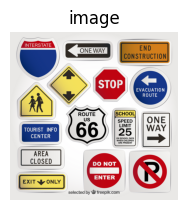

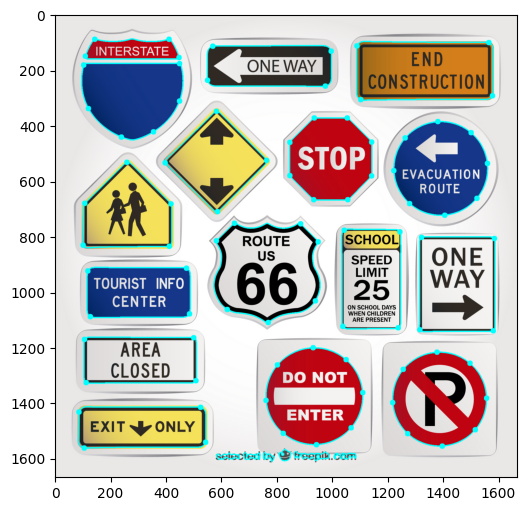

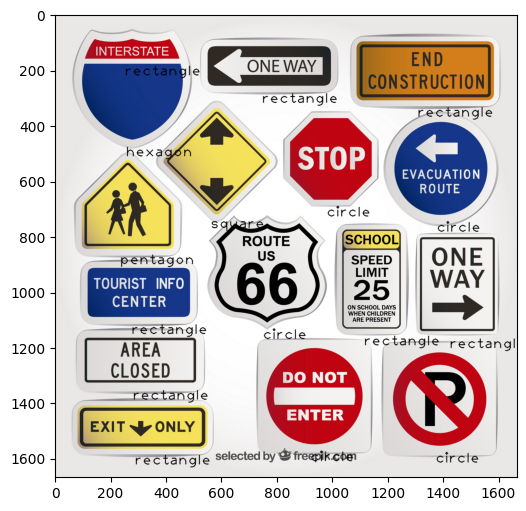

In [107]:


# Make a copy to draw the results:
image_contours = image.copy()
image_recognition_shapes = image.copy()

#just restrict to selected level, level0 is parent
contours = selected_contours

# Draw the outline of all detected contours:
draw_contour_outline(image_contours, contours, (255, 255, 0), 4)

for contour in contours:
    # Compute the moments of the current contour:
    area = cv2.contourArea(contour)

    if area < 2500: continue # filter contours by area BEFORE moments.Remove noise
    M = cv2.moments(contour)
    #eliminate small text/noise usually in shape rectangle

    # Calculate the centroid of the contour from the moments:
    if M["m00"] != 0:
        cX = int(M['m10'] / M['m00'])
        cY = int(M['m01'] / M['m00'])
    # Detect shape of the current contour:
    shape, vertices = detect_shape(contour)

    # Draw the detected vertices:
   
    draw_contour_points(image_contours, [vertices], (255, 255, 0))

    # Get the position to draw:
    #(x, y) = get_position_to_draw(shape, (cX, cY), cv2.FONT_HERSHEY_SIMPLEX, 1.6, 3)
    (x, y) = get_txt_position_under_shape(shape, contour, cv2.FONT_HERSHEY_PLAIN, 0.7, 2
)

    # Write the name of shape on the center of shapes
    print(f"\nName {shape}\n")
    cv2.putText(image_recognition_shapes, shape, (x, y), cv2.FONT_HERSHEY_PLAIN, 3.5, (0, 0, 0), 2,cv2.LINE_AA)

# Plot the images
show_img_with_matplotlib(image, "image", 1)
#show_img_with_matplotlib(cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR), "threshold", 2)
#show_img_with_matplotlib(image_contours, "contours outline (after approximation)", 3)
display_img(image_contours)
#show_img_with_matplotlib(image_recognition_shapes, "contours recognition", 4)
display_img(image_recognition_shapes)

# Show the Figure:
plt.show()